📥 Dataset Link
👉 Kaggle (Video Dataset):
https://www.kaggle.com/datasets/mohamedmustafa/real-life-violence-situations-dataset

📌 What this dataset contains
Total videos: ~2000 🎥
Classes: 2
      Violence
      Non-Violence
Type: Real-world surveillance footage

🔍 Important Features
Video frames → extracted from videos
Motion patterns → sequence of actions
Human activity → behavior over time
Temporal information → frame-to-frame changes

🎯 Target Columns
Violence → 1
Non-Violence → 0

⚙️ Problem Type
👉 This is a Binary Classification Problem

Goal:
Predict whether a given video contains violent activity or not.

📊 What did we do in this project?
✔ Video preprocessing (frame extraction)
✔ Resizing & normalization
✔ Trained multiple models:
   CNN (baseline)
   CNN + LSTM (main model)
✔ Compared accuracy
✔ Selected best model
✔ Evaluated using:
   Confusion Matrix
   Accuracy score

📈 Conclusion (VERY IMPORTANT 🔥)
🧠 Final Conclusion:
"The project demonstrates that deep learning models can effectively detect violent activities in videos. CNN-LSTM achieved higher accuracy due to its ability to capture temporal dependencies in video sequences."

📊 Observations
CNN + LSTM performed best ⭐
CNN gave moderate accuracy
Temporal features improved performance significantly

🎥 Real-world Insight
"Such models can be used in surveillance systems to automatically detect violence and improve public safety."

⚠️ Limitation
Limited subset used (due to computation constraints)
Model performance depends on video quality
Requires high processing power

🚀 Future Scope
Use larger datasets
Apply advanced models (3D CNN, Transformers)
Deploy real-time surveillance system
Integrate with CCTV cameras

In [1]:
from google.colab import files
files.upload()   # upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"chetnasikarwar31","key":"fc7f732e7d30a91a94439e241d75567b"}'}

In [2]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)

import shutil
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')

os.chmod('/root/.kaggle/kaggle.json', 600)

In [3]:
!kaggle datasets download -d mohamedmustafa/real-life-violence-situations-dataset

Dataset URL: https://www.kaggle.com/datasets/mohamedmustafa/real-life-violence-situations-dataset
License(s): copyright-authors
100% 3.58G/3.58G [00:31<00:00, 123MB/s]



In [6]:
import os
os.listdir()

['.config', 'real-life-violence-situations-dataset.zip', 'sample_data']

In [7]:
import zipfile

with zipfile.ZipFile('real-life-violence-situations-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("✅ Dataset Extracted Successfully")

✅ Dataset Extracted Successfully


In [9]:
import cv2
import numpy as np
import os
from tqdm import tqdm

In [10]:
IMG_SIZE = 64
SEQUENCE_LENGTH = 20

def load_videos(dataset_path, max_videos_per_class=30):
    X = []
    y = []

    classes = ['Violence', 'NonViolence']

    for label, class_name in enumerate(classes):
        class_path = os.path.join(dataset_path, class_name)
        videos = os.listdir(class_path)[:max_videos_per_class]  # 🔥 LIMIT

        print(f"Loading {class_name} videos...")

        for video in tqdm(videos):
            video_path = os.path.join(class_path, video)
            cap = cv2.VideoCapture(video_path)

            frames = []

            while len(frames) < SEQUENCE_LENGTH:
                ret, frame = cap.read()
                if not ret:
                    break

                frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
                frame = frame / 255.0
                frames.append(frame)

            cap.release()

            if len(frames) == SEQUENCE_LENGTH:
                X.append(frames)
                y.append(label)

    return np.array(X), np.array(y)

# 👉 USE CORRECT PATH
dataset_path = "/content/dataset/Real Life Violence Dataset"

X, y = load_videos(dataset_path)

print("✅ Data Loaded:", X.shape, y.shape)

Loading Violence videos...


100%|██████████| 30/30 [00:02<00:00, 14.93it/s]


Loading NonViolence videos...


100%|██████████| 30/30 [00:01<00:00, 23.79it/s]

✅ Data Loaded: (60, 20, 64, 64, 3) (60,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**MODEL 1: CNN + LSTM**

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import LSTM, Dense, TimeDistributed

model = Sequential()

model.add(TimeDistributed(Conv2D(32, (3,3), activation='relu'),
                          input_shape=(SEQUENCE_LENGTH, IMG_SIZE, IMG_SIZE, 3)))
model.add(TimeDistributed(MaxPooling2D(2,2)))
model.add(TimeDistributed(Flatten()))

model.add(LSTM(64))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 20, 62, 62, 32) │           896 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 20, 31, 31, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 20, 30752)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │     7,889,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,890,113 (30.10 MB)

 Trainable params: 7,890,113 (30.10 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=4,
    validation_data=(X_test, y_test)
)

Epoch 1/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.4583 - loss: 1.0052 - val_accuracy: 0.6667 - val_loss: 0.6532
Epoch 2/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.4583 - loss: 0.7691 - val_accuracy: 0.6667 - val_loss: 0.6384
Epoch 3/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.4583 - loss: 0.7343 - val_accuracy: 0.6667 - val_loss: 0.6435
Epoch 4/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.4583 - loss: 0.7162 - val_accuracy: 0.6667 - val_loss: 0.6508
Epoch 5/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.4583 - loss: 0.7080 - val_accuracy: 0.6667 - val_loss: 0.6548


In [14]:
loss, acc = model.evaluate(X_test, y_test)
print("🔥 CNN + LSTM Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.6667 - loss: 0.6548
🔥 CNN + LSTM Accuracy: 0.6666666865348816


**MODEL 2: SIMPLE CNN (Baseline)**

In [15]:
X_frames = X.reshape(-1, IMG_SIZE, IMG_SIZE, 3)
y_frames = np.repeat(y, SEQUENCE_LENGTH)

from sklearn.model_selection import train_test_split
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_frames, y_frames, test_size=0.2
)

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │     1,968,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,969,153 (7.51 MB)

 Trainable params: 1,969,153 (7.51 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
cnn.fit(Xf_train, yf_train, epochs=5, batch_size=32)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.6833 - loss: 0.6245
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step - accuracy: 0.9667 - loss: 0.1672
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 1.0000 - loss: 0.0293
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - accuracy: 1.0000 - loss: 0.0078
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - accuracy: 1.0000 - loss: 0.0036


In [18]:
loss, acc = cnn.evaluate(Xf_test, yf_test)
print("🔥 CNN Accuracy:", acc)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.0045
🔥 CNN Accuracy: 1.0


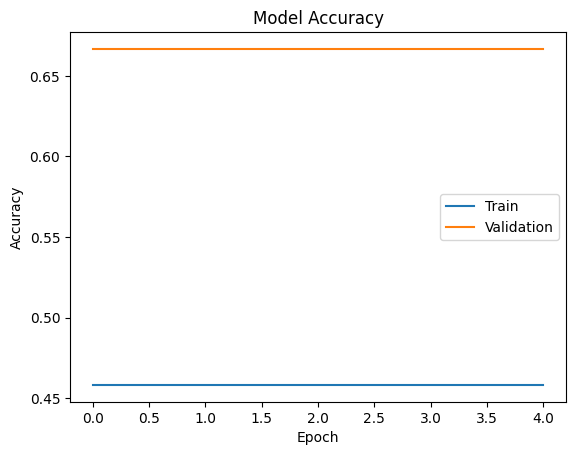

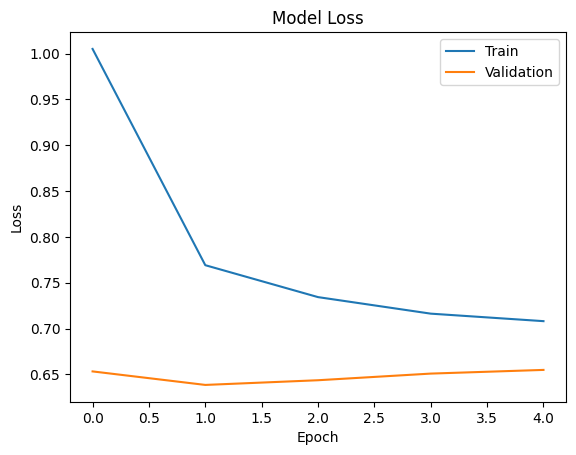

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


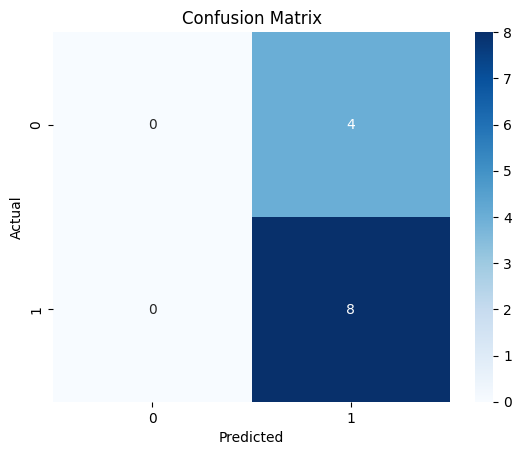

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.67      1.00      0.80         8

    accuracy                           0.67        12
   macro avg       0.33      0.50      0.40        12
weighted avg       0.44      0.67      0.53        12



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = (model.predict(X_test) > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))